# TrafficGuard : MIO-TCD Data Pipeline & Congestion Labelling

full data pipeline 
1. Load and clean the MIO-TCD Localization dataset
2. Filter to vehicle-only annotations (exclude pedestrians)
3. Compute per-image congestion features using convex hull boundary analysis
4. Calibrate thresholds from the data distribution
5. Assign Low / Medium / High congestion labels
6. Validate labels with visual spot-checks
7. Produce stratified train / val / test split
8. Save the final labelled manifest for model training

## 0. Setup & Imports

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import cv2
from scipy.spatial import ConvexHull, QhullError
from sklearn.model_selection import train_test_split
from pathlib import Path

# Paths 
# Update base_path to your local MIO-TCD-Localization folder
BASE_PATH   = Path(r'C:\Users\riana\Downloads\missiongrad\MIO-TCD-Localization')
GT_CSV      = BASE_PATH / 'gt_train.csv'
IMAGES_DIR  = BASE_PATH / 'train'
OUTPUT_DIR  = BASE_PATH / 'pipeline_output'
OUTPUT_DIR.mkdir(exist_ok=True)

print('Paths set. Base:', BASE_PATH)
print('Output will be saved to:', OUTPUT_DIR)

Paths set. Base: C:\Users\riana\Downloads\missiongrad\MIO-TCD-Localization
Output will be saved to: C:\Users\riana\Downloads\missiongrad\MIO-TCD-Localization\pipeline_output


## 1. Load & Clean the Dataset

In [2]:
cols = ['image_id', 'label', 'x1', 'y1', 'x2', 'y2']
df_raw = pd.read_csv(GT_CSV, names=cols, header=None, dtype={'image_id': str})

print(f'Total raw annotations : {len(df_raw):,}')
print(f'Unique images         : {df_raw["image_id"].nunique():,}')
print(f'\nAll labels found:')
print(df_raw['label'].value_counts())

Total raw annotations : 351,549
Unique images         : 110,000

All labels found:
label
car                      233497
pickup_truck              44283
motorized_vehicle         25845
bus                       10598
articulated_truck          9301
work_van                   8709
pedestrian                 7128
single_unit_truck          5741
non-motorized_vehicle      2350
bicycle                    2260
motorcycle                 1837
Name: count, dtype: int64


In [3]:
# drop rows with any missing values or invalid bounding boxes
df_raw = df_raw.dropna()
df_raw = df_raw[(df_raw['x2'] > df_raw['x1']) & (df_raw['y2'] > df_raw['y1'])]

# exclude pedestrians (vehicle-based congestion only)
EXCLUDE_LABELS = ['pedestrian']
df = df_raw[~df_raw['label'].isin(EXCLUDE_LABELS)].copy()

print(f'Annotations after cleaning     : {len(df_raw):,}')
print(f'Annotations after excl. peds   : {len(df):,}')
print(f'Unique images (vehicles only)  : {df["image_id"].nunique():,}')

Annotations after cleaning     : 351,544
Annotations after excl. peds   : 344,416
Unique images (vehicles only)  : 109,988


## section 2

For each image we compute five spatial features:

| Feature | Description |
|---|---|
| `vehicle_count` | Number of vehicles in the image |
| `hull_area` | Area of the convex hull drawn around all vehicle centroids |
| `hull_coverage` | Hull area as a fraction of image area (0–1) |
| `packing_density` | Vehicles per unit of hull area — distinguishes a dense cluster from the same count spread far apart |
| `mean_nn_dist_norm` | Mean nearest-neighbour distance between centroids, normalised by image diagonal — penalises large inter-vehicle gaps |

The composite score weights these so that a handful of vehicles spread across an empty road stays Low, even if the raw count would place it in the upper percentile of the dataset.


In [4]:
IMAGE_W, IMAGE_H = 1920, 1080  # MIO-TCD standard resolution
IMAGE_AREA = IMAGE_W * IMAGE_H
IMAGE_DIAG = (IMAGE_W**2 + IMAGE_H**2) ** 0.5  # normalisation baseline for distances

def compute_centroid(row):
    cx = (row['x1'] + row['x2']) / 2
    cy = (row['y1'] + row['y2']) / 2
    return cx, cy

def compute_convex_hull_area(centroids):
    if len(centroids) < 3:
        return 0.0
    try:
        hull = ConvexHull(centroids)
        return hull.volume  # In 2D, hull.volume == area
    except QhullError:
        return 0.0

def compute_mean_nn_distance(centroids):
    """
    Mean distance from each centroid to its nearest neighbour.
    Returns 0 for single-vehicle images (nothing to compare against).
    A high value means vehicles are spread far apart — sparse traffic.
    """
    n = len(centroids)
    if n < 2:
        return 0.0
    pts = np.array(centroids)
    # pairwise squared distances — vectorised, no scipy dependency
    diff = pts[:, None, :] - pts[None, :, :]          # (n, n, 2)
    dist2 = (diff ** 2).sum(axis=-1)                  # (n, n)
    np.fill_diagonal(dist2, np.inf)                   # ignore self
    nn_dist = np.sqrt(dist2.min(axis=1))               # nearest neighbour per vehicle
    return float(nn_dist.mean())

def extract_features_for_image(group):
    vehicle_count = len(group)
    centroids = np.array([compute_centroid(row) for _, row in group.iterrows()])

    hull_area    = compute_convex_hull_area(centroids)
    hull_coverage = hull_area / IMAGE_AREA            # fraction 0–1

    # vehicles per pixel² of hull — high when cars are tightly packed
    packing_density = vehicle_count / hull_area if hull_area > 0 else 0.0

    # mean nearest-neighbour distance, normalised to [0, 1] by image diagonal
    mean_nn_dist_norm = compute_mean_nn_distance(centroids) / IMAGE_DIAG

    return pd.Series({
        'vehicle_count':    vehicle_count,
        'hull_area':        hull_area,
        'hull_coverage':    hull_coverage,
        'packing_density':  packing_density,
        'mean_nn_dist_norm': mean_nn_dist_norm,
    })

print('Extracting features per image...')
features_df = (
    df.groupby('image_id')
      .apply(extract_features_for_image)
      .reset_index()
)

print(f'Features extracted for {len(features_df):,} images')
print(features_df.columns.tolist())
features_df.head()


Extracting features per image...
Features extracted for 109,988 images
['image_id', 'vehicle_count', 'hull_area', 'hull_coverage', 'packing_density', 'mean_nn_dist_norm']


C:\Users\riana\AppData\Local\Temp\ipykernel_15260\1954365273.py:60: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(extract_features_for_image)


,image_id,vehicle_count,hull_area,hull_coverage,packing_density,mean_nn_dist_norm
0,00000000,5.0,5386.50,0.002598,0.000928,0.022568
1,00000001,6.0,17160.25,0.008276,0.000350,0.035581
2,00000002,1.0,0.00,0.000000,0.000000,0.000000
3,00000003,2.0,0.00,0.000000,0.000000,0.101714
4,00000004,1.0,0.00,0.000000,0.000000,0.000000


## 3. Calibrate Congestion Thresholds

We look at the distribution of `vehicle_count` across all images to decide where to place the Low / Medium / High boundaries. used percentile-based splitting to ensure roughly equal class sizes.

In [5]:
vc = features_df['vehicle_count']

def minmax(series):
    mn, mx = series.min(), series.max()
    return (series - mn) / (mx - mn) if mx > mn else series * 0

vc_norm      = minmax(features_df['vehicle_count'])
pack_norm    = minmax(features_df['packing_density'])   # high = dense = more congested
nn_norm      = minmax(features_df['mean_nn_dist_norm']) # high = spread out = less congested

# Composite score
#   + vehicle count  (how many vehicles)
#   + packing density (how tightly clustered)
#   - mean NN distance (penalise sparse spread)
#
# The NN term is *subtracted*: if vehicles are far apart, the score drops,
# preventing 3–4 spread-out cars from being labelled Medium/High.
# clip(0, 1) keeps the score in range after the subtraction.
raw_score = 0.5 * vc_norm + 0.35 * pack_norm - 0.15 * nn_norm
features_df['density_score'] = raw_score.clip(lower=0).pipe(minmax)

p33 = features_df['density_score'].quantile(0.33)
p76 = features_df['density_score'].quantile(0.76)

print('Vehicle count distribution:')
print(vc.describe().round(2))
print(f'\nDensity score distribution:')
print(features_df['density_score'].describe().round(4))
print(f'\n33rd percentile (Low/Med boundary)  : {p33:.4f}')
print(f'76th percentile (Med/High boundary) : {p76:.4f}')


Vehicle count distribution:
count    109988.00
mean          3.13
std           2.81
min           1.00
25%           1.00
50%           2.00
75%           4.00
max          32.00
Name: vehicle_count, dtype: float64

Density score distribution:
count    109988.0000
mean          0.0418
std           0.0866
min           0.0000
25%           0.0000
50%           0.0000
75%           0.0508
max           1.0000
Name: density_score, dtype: float64

33rd percentile (Low/Med boundary)  : 0.0000
76th percentile (Med/High boundary) : 0.0560


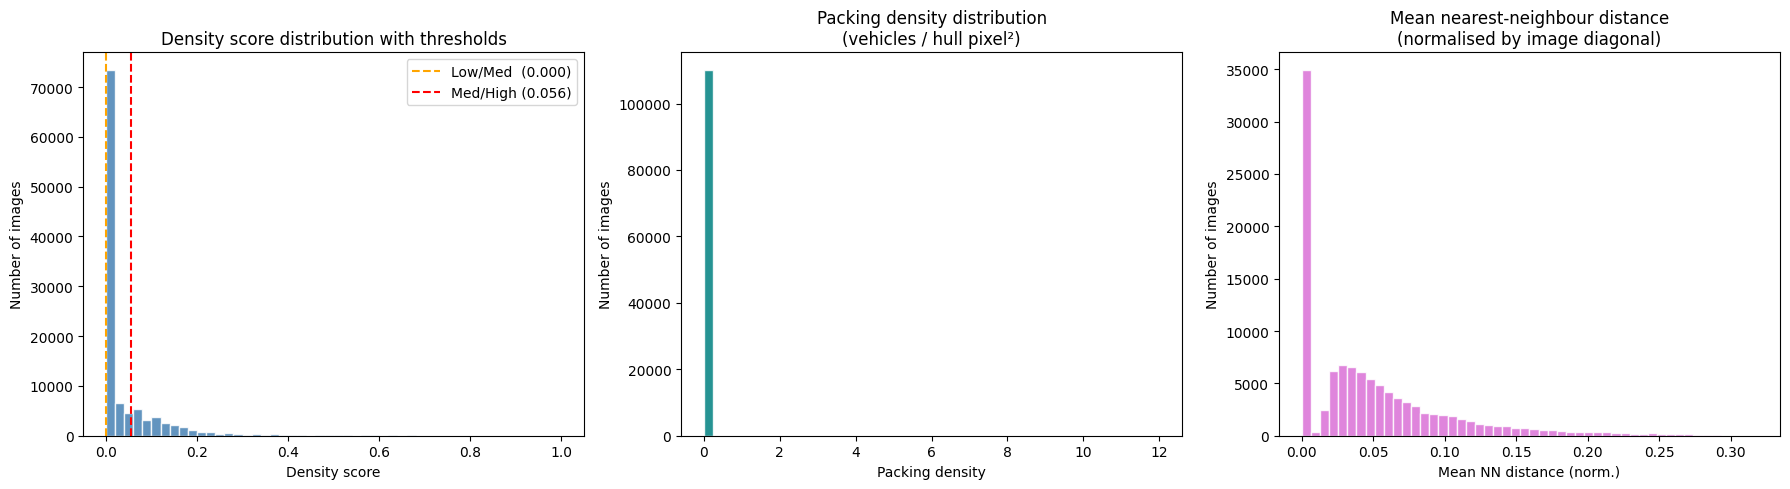

Plot saved.


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# density_score distribution with threshold lines
axes[0].hist(features_df['density_score'], bins=50, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(p33, color='orange', linestyle='--', linewidth=1.5, label=f'Low/Med  ({p33:.3f})')
axes[0].axvline(p76, color='red',    linestyle='--', linewidth=1.5, label=f'Med/High ({p76:.3f})')
axes[0].set_title('Density score distribution with thresholds')
axes[0].set_xlabel('Density score')
axes[0].set_ylabel('Number of images')
axes[0].legend()

# Packing density
axes[1].hist(features_df['packing_density'], bins=50, color='teal', edgecolor='white', alpha=0.85)
axes[1].set_title('Packing density distribution\n(vehicles / hull pixel²)')
axes[1].set_xlabel('Packing density')
axes[1].set_ylabel('Number of images')

# Mean nearest-neighbour distance
axes[2].hist(features_df['mean_nn_dist_norm'], bins=50, color='orchid', edgecolor='white', alpha=0.85)
axes[2].set_title('Mean nearest-neighbour distance\n(normalised by image diagonal)')
axes[2].set_xlabel('Mean NN distance (norm.)')
axes[2].set_ylabel('Number of images')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'threshold_distributions.png', dpi=120)
plt.show()
print('Plot saved.')


## 4. Assign Congestion Labels

Apply the calibrated thresholds to produce the three-class label for every image.

In [7]:
# Thresholds 
# override them manually here if needed 
p33 = features_df['density_score'].quantile(0.33)
p76 = features_df['density_score'].quantile(0.76)

def assign_label(score):
    if score <= p33:
        return 'Low'
    elif score <= p76:
        return 'Medium'
    else:
        return 'High'

features_df['congestion_label'] = features_df['density_score'].apply(assign_label)
label_counts = features_df['congestion_label'].value_counts()
print('Class distribution after labelling:')
print(label_counts)
print(f'\nTotal labelled images: {len(features_df):,}')

Class distribution after labelling:
congestion_label
Low       66075
High      26397
Medium    17516
Name: count, dtype: int64

Total labelled images: 109,988


Image ID: 00039024 contains 32 objects.


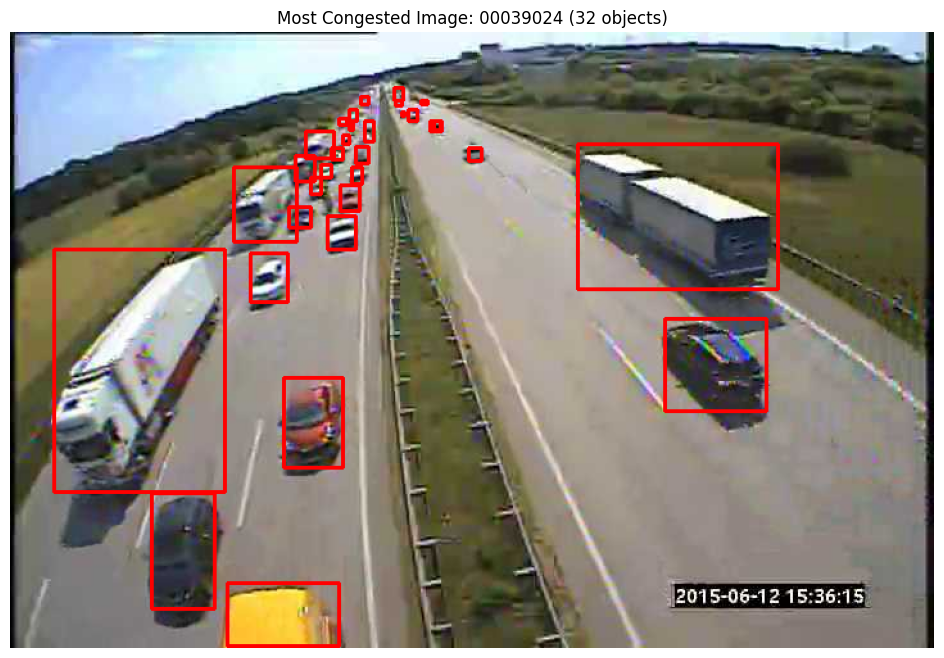

In [8]:
# find the image ID with the maximum object count
max_img_id = df.groupby('image_id').size().idxmax()
max_count = df.groupby('image_id').size().max()

print(f"Image ID: {max_img_id} contains {max_count} objects.")

# path to the image 
img_path = os.path.join(BASE_PATH, 'train', f"{max_img_id}.jpg")

img = cv2.imread(img_path)
if img is not None:
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # draw bounding boxes
    for _, row in df[df['image_id'] == max_img_id].iterrows():
        cv2.rectangle(img_rgb, (int(row['x1']), int(row['y1'])), (int(row['x2']), int(row['y2'])), (255, 0, 0), 2)
    
    plt.figure(figsize=(12, 8))
    plt.imshow(img_rgb)
    plt.title(f"Most Congested Image: {max_img_id} ({max_count} objects)")
    plt.axis('off')
    plt.show()
else:
    print("Image not found. Please check the 'base_path' and 'train' directory.")

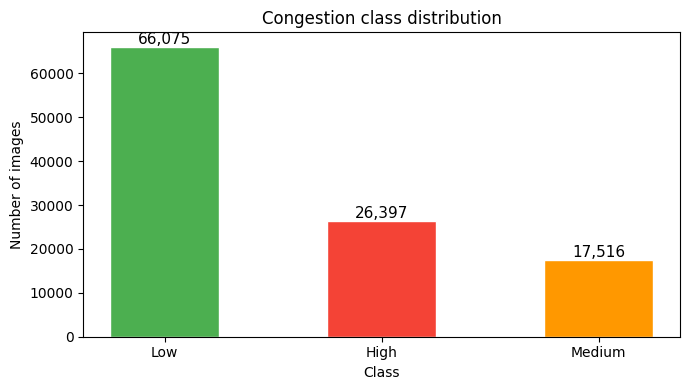

Plot saved.


In [9]:
# bar chart of class distribution
colors = {'Low': '#4CAF50', 'Medium': '#FF9800', 'High': '#F44336'}
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(
    label_counts.index,
    label_counts.values,
    color=[colors[l] for l in label_counts.index],
    edgecolor='white',
    width=0.5
)
for bar, val in zip(bars, label_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            f'{val:,}', ha='center', va='bottom', fontsize=11)
ax.set_title('Congestion class distribution')
ax.set_xlabel('Class')
ax.set_ylabel('Number of images')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'class_distribution.png', dpi=120)
plt.show()
print('Plot saved.')

## 5. Visual Validation

check manually. If something looks wrong, adjust the thresholds in section 4 and re-run.

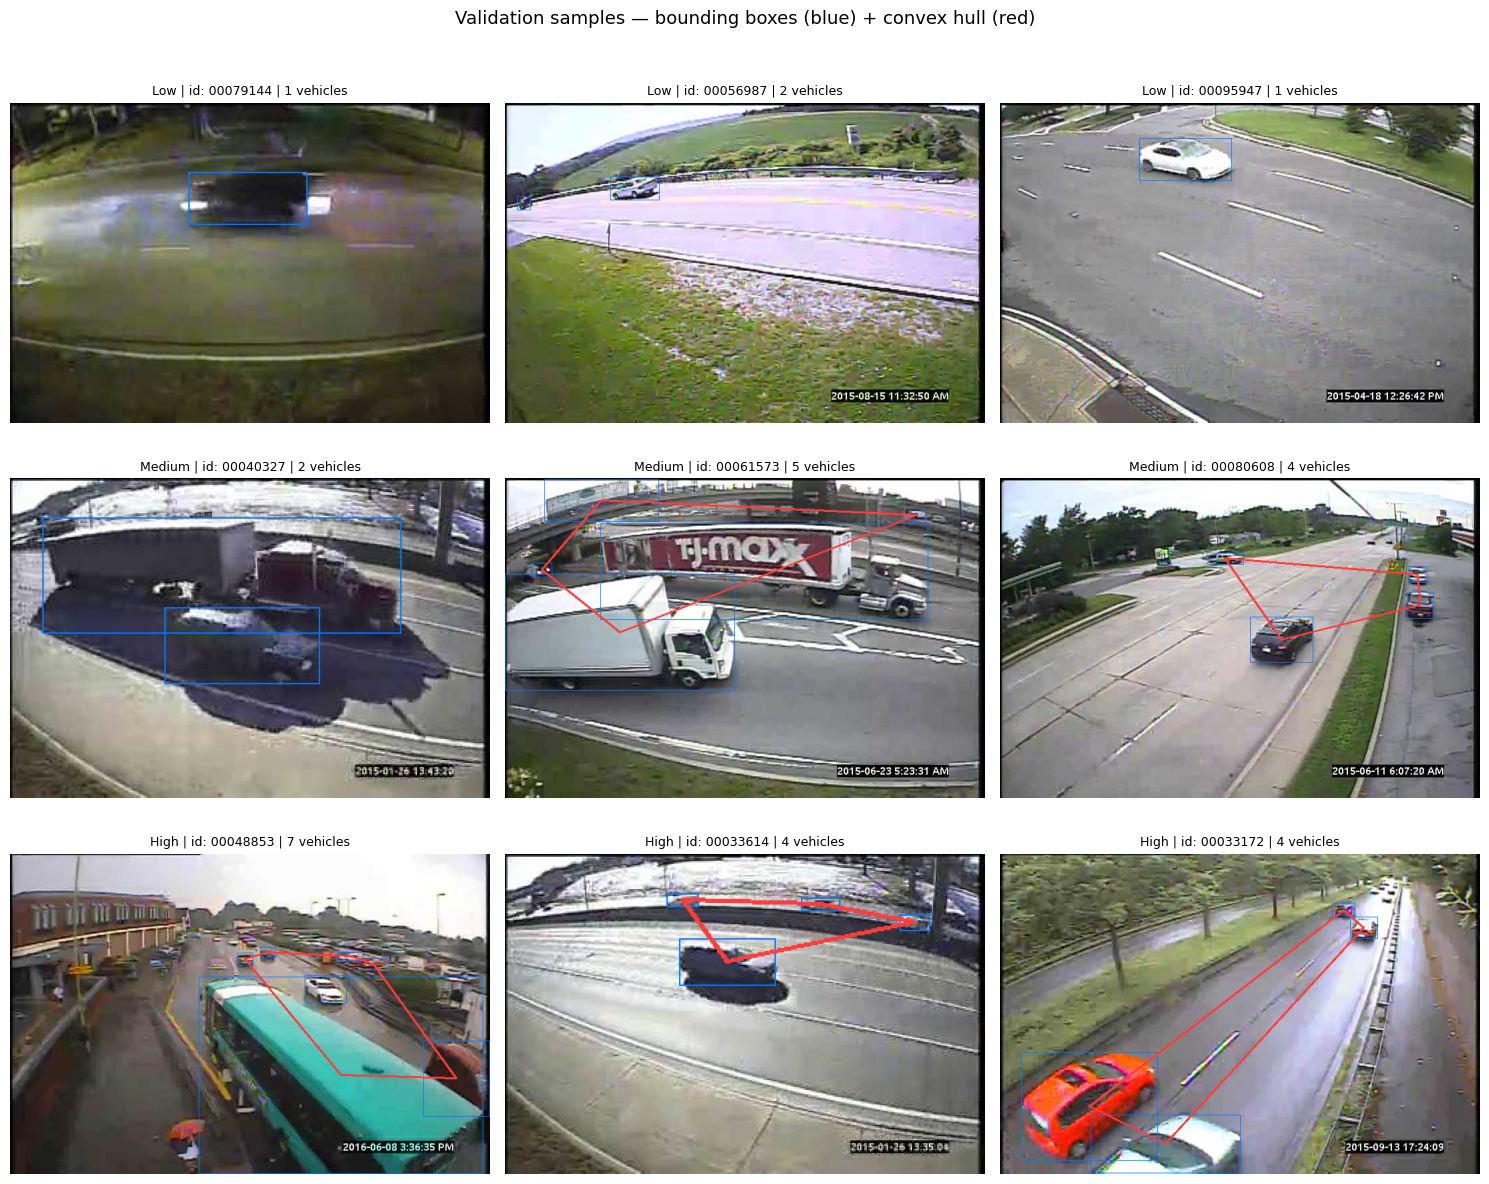

Validation plot saved.


In [10]:
def draw_image_with_hull(image_id, label, annotations_df, images_dir):
    """
    Load an image, draw bounding boxes for all vehicles, and overlay the
    convex hull boundary around vehicle centroids.
    Returns the annotated RGB image, or None if the image file is missing.
    """
    img_path = Path(images_dir) / f'{image_id}.jpg'
    img = cv2.imread(str(img_path))
    if img is None:
        return None
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    rows = annotations_df[annotations_df['image_id'] == image_id]

    # Draw bounding boxes
    for _, row in rows.iterrows():
        x1, y1, x2, y2 = int(row['x1']), int(row['y1']), int(row['x2']), int(row['y2'])
        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 120, 255), 1)

    # Compute and draw convex hull
    centroids = np.array([
        [(row['x1'] + row['x2']) / 2, (row['y1'] + row['y2']) / 2]
        for _, row in rows.iterrows()
    ])
    if len(centroids) >= 3:
        try:
            hull = ConvexHull(centroids)
            hull_pts = centroids[hull.vertices].astype(np.int32)
            cv2.polylines(img, [hull_pts], isClosed=True, color=(255, 60, 60), thickness=2)
        except QhullError:
            pass

    return img


def visualise_samples(features_df, annotations_df, images_dir, n_per_class=3):
    """
    Display n_per_class randomly sampled images for each congestion class.
    """
    classes = ['Low', 'Medium', 'High']
    fig, axes = plt.subplots(len(classes), n_per_class, figsize=(5 * n_per_class, 4 * len(classes)))

    for row_idx, cls in enumerate(classes):
        sample_ids = (
            features_df[features_df['congestion_label'] == cls]
            ['image_id']
            .sample(min(n_per_class, sum(features_df['congestion_label'] == cls)),
                    random_state=42)
            .tolist()
        )
        for col_idx in range(n_per_class):
            ax = axes[row_idx][col_idx]
            ax.axis('off')
            if col_idx < len(sample_ids):
                img = draw_image_with_hull(
                    sample_ids[col_idx], cls, annotations_df, images_dir
                )
                if img is not None:
                    ax.imshow(img)
                    vc = int(features_df.loc[
                        features_df['image_id'] == sample_ids[col_idx], 'vehicle_count'
                    ].values[0])
                    ax.set_title(f'{cls} | id: {sample_ids[col_idx]} | {vc} vehicles',
                                 fontsize=9)
                else:
                    ax.set_title(f'{cls} — image not found', fontsize=9)

    fig.suptitle('Validation samples — bounding boxes (blue) + convex hull (red)',
                 fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'validation_samples.png', dpi=100, bbox_inches='tight')
    plt.show()
    print('Validation plot saved.')


visualise_samples(features_df, df, IMAGES_DIR, n_per_class=3)

## 6. Train / Validation / Test Split

stratified 70 / 15 / 15 split so each congestion class is proportionally represented in all three sets.

In [11]:
TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15
RANDOM_SEED = 42

# Split off test set first
train_val, test_df = train_test_split(
    features_df,
    test_size=TEST_RATIO,
    stratify=features_df['congestion_label'],
    random_state=RANDOM_SEED
)

# Split remaining into train and val
val_adjusted = VAL_RATIO / (TRAIN_RATIO + VAL_RATIO)
train_df, val_df = train_test_split(
    train_val,
    test_size=val_adjusted,
    stratify=train_val['congestion_label'],
    random_state=RANDOM_SEED
)

# Assign split column
train_df = train_df.copy(); train_df['split'] = 'train'
val_df   = val_df.copy();   val_df['split']   = 'val'
test_df  = test_df.copy();  test_df['split']  = 'test'

manifest = pd.concat([train_df, val_df, test_df]).reset_index(drop=True)

print('Split sizes:')
print(f'  Train : {len(train_df):,}')
print(f'  Val   : {len(val_df):,}')
print(f'  Test  : {len(test_df):,}')
print(f'  Total : {len(manifest):,}')

Split sizes:
  Train : 76,990
  Val   : 16,499
  Test  : 16,499
  Total : 109,988


Class distribution per split:
congestion_label   High    Low  Medium
split                                 
test               3960   9912    2627
train             18477  46251   12262
val                3960   9912    2627


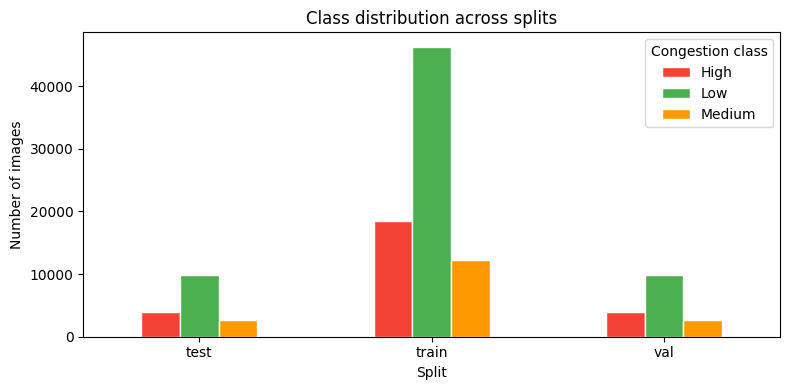

Plot saved.


In [12]:
# Verify class balance is preserved across splits
print('Class distribution per split:')
balance = (
    manifest.groupby(['split', 'congestion_label'])
    .size()
    .unstack(fill_value=0)
)
print(balance)

# Plot
balance.plot(kind='bar', figsize=(8, 4), color=['#F44336', '#4CAF50', '#FF9800'],
             edgecolor='white')
plt.title('Class distribution across splits')
plt.xlabel('Split')
plt.ylabel('Number of images')
plt.xticks(rotation=0)
plt.legend(title='Congestion class')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'split_distribution.png', dpi=120)
plt.show()
print('Plot saved.')

## 7. Save Final Manifest
idk what manifest means :`)

In [13]:
# build image path column so the training script can locate each file
manifest['image_path'] = manifest['image_id'].apply(
    lambda x: str(IMAGES_DIR / f'{x}.jpg')
)

# reorder columns (includes the two new spatial features)
manifest = manifest[['image_id', 'image_path', 'vehicle_count',
                      'hull_area', 'hull_coverage',
                      'packing_density', 'mean_nn_dist_norm',
                      'density_score', 'congestion_label', 'split']]

# save
manifest_path = OUTPUT_DIR / 'labelled_manifest.csv'
manifest.to_csv(manifest_path, index=False)

print(f'Manifest saved to: {manifest_path}')
print(f'Total images in manifest: {len(manifest):,}')
manifest.head(10)


Manifest saved to: C:\Users\riana\Downloads\missiongrad\MIO-TCD-Localization\pipeline_output\labelled_manifest.csv
Total images in manifest: 109,988


,image_id,image_path,vehicle_count,hull_area,hull_coverage,packing_density,mean_nn_dist_norm,density_score,congestion_label,split
0,00086778,C:\Users\riana\Downloads\missiongrad\MIO-TCD-L...,1.0,0.00,0.000000,0.000000,0.000000,0.000000,Low,train
1,00063702,C:\Users\riana\Downloads\missiongrad\MIO-TCD-L...,3.0,11339.25,0.005468,0.000265,0.066336,0.002059,Medium,train
2,00072743,C:\Users\riana\Downloads\missiongrad\MIO-TCD-L...,4.0,28500.75,0.013745,0.000140,0.072531,0.028662,Medium,train
3,00067449,C:\Users\riana\Downloads\missiongrad\MIO-TCD-L...,7.0,17054.75,0.008225,0.000410,0.026900,0.169433,High,train
4,00053748,C:\Users\riana\Downloads\missiongrad\MIO-TCD-L...,1.0,0.00,0.000000,0.000000,0.000000,0.000000,Low,train
5,00020467,C:\Users\riana\Downloads\missiongrad\MIO-TCD-L...,1.0,0.00,0.000000,0.000000,0.000000,0.000000,Low,train
6,00082126,C:\Users\riana\Downloads\missiongrad\MIO-TCD-L...,2.0,0.00,0.000000,0.000000,0.129952,0.000000,Low,train
7,00010149,C:\Users\riana\Downloads\missiongrad\MIO-TCD-L...,3.0,6933.75,0.003344,0.000433,0.054240,0.013544,Medium,train
8,00099237,C:\Users\riana\Downloads\missiongrad\MIO-TCD-L...,1.0,0.00,0.000000,0.000000,0.000000,0.000000,Low,train
9,00036356,C:\Users\riana\Downloads\missiongrad\MIO-TCD-L...,4.0,29604.25,0.014277,0.000135,0.082768,0.018950,Medium,train


## 8. Pipeline Summary

Quick sanity check - print key statistics for the final report.

In [15]:
print('TRAFFICGUARD - DATA PIPELINE SUMMARY')
print(f'Dataset : MIO-TCD Localization')
print(f'Raw annotations : {len(df_raw):,}')
print(f'After filtering : {len(df):,} (vehicles only)')
print(f'Images labelled : {len(manifest):,}')
print(f'')
print(f'Thresholds used (density_score):')
print(f'  Low    : density_score <= {p33:.4f}')
print(f'  Medium : {p33:.4f} < density_score <= {p76:.4f}')
print(f'  High   : density_score > {p76:.4f}')
print(f'  (score = 0.5*count + 0.35*packing_density - 0.15*mean_nn_dist, normalised)')
print(f'')
print(f'Class breakdown  :')
for cls, count in manifest['congestion_label'].value_counts().items():
    pct = count / len(manifest) * 100
    print(f'{cls:<8} : {count:>5,}  ({pct:.1f}%)')
print(f'')
print(f'Split sizes:')
for split, count in manifest['split'].value_counts().items():
    print(f'{split:<6} : {count:>5,}')
print(f'')
print(f'  Output saved to  : {OUTPUT_DIR}')

TRAFFICGUARD - DATA PIPELINE SUMMARY
Dataset : MIO-TCD Localization
Raw annotations : 351,544
After filtering : 344,416 (vehicles only)
Images labelled : 109,988

Thresholds used (density_score):
  Low    : density_score <= 0.0000
  Medium : 0.0000 < density_score <= 0.0560
  High   : density_score > 0.0560
  (score = 0.5*count + 0.35*packing_density - 0.15*mean_nn_dist, normalised)

Class breakdown  :
Low      : 66,075  (60.1%)
High     : 26,397  (24.0%)
Medium   : 17,516  (15.9%)

Split sizes:
train  : 76,990
val    : 16,499
test   : 16,499

  Output saved to  : C:\Users\riana\Downloads\missiongrad\MIO-TCD-Localization\pipeline_output
